In [1]:
import pandas as pd#read csv,parquet
import numpy as np#for scientific computation of matrices
from  lightgbm import LGBMRegressor,LGBMClassifier,log_evaluation,early_stopping
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer#word2vec feature
import warnings#avoid some negligible errors
#The filterwarnings () method is used to set warning filters, which can control the output method and level of warning information.
warnings.filterwarnings('ignore')
import random#provide some function to generate random_seed.
#set random seed,to make sure model can be recurrented.
def seed_everything(seed):
    np.random.seed(seed)#numpy's random seed
    random.seed(seed)#python built-in random seed
seed_everything(seed=2025)

In [2]:
# Feature Engineering
def get_feats(mode='train'):
    path = f'/kaggle/input/phems-hackathon-early-sepsis-prediction/{mode}ing_data/'
    feats = pd.read_csv(path + f"SepsisLabel_{mode}.csv").drop_duplicates()
    feats['measurement_datetime_day'] = feats['measurement_datetime'].fillna('None').astype(str).apply(lambda x: x[:10])

    # Drug Features
    drug = pd.read_csv(path + f"drugsexposure_{mode}.csv")
    drug['measurement_datetime_day'] = drug['drug_datetime_hourly'].fillna('None').astype(str).apply(lambda x: x[:10])
    for col in ['drug_concept_id', 'route_concept_id']:
        drug[col] = drug[col].fillna('None').astype(str)
        group_df = drug.groupby(['person_id', 'measurement_datetime_day'])[col].apply(lambda x: " ".join(x)).reset_index()
        feats = feats.merge(group_df, on=['person_id', 'measurement_datetime_day'], how='left')
        feats[col] = feats[col].fillna('None')

    # Time-Based Features
    feats['measurement_datetime'] = pd.to_datetime(feats['measurement_datetime'])
    feats['dow'] = feats['measurement_datetime'].dt.dayofweek
    feats['doy'] = feats['measurement_datetime'].dt.dayofyear
    feats['hour'] = feats['measurement_datetime'].dt.hour
    feats.drop(['measurement_datetime'], axis=1, inplace=True)

    # Convert categorical columns to category dtype
    feats['measurement_datetime_day'] = feats['measurement_datetime_day'].astype('category')
    feats['drug_concept_id'] = feats['drug_concept_id'].astype('category')
    feats['route_concept_id'] = feats['route_concept_id'].astype('category')

    return feats

# Load Data
train = get_feats(mode='train')
test = get_feats(mode='test')

# TF-IDF for Text Features
text_cols = ['drug_concept_id', 'route_concept_id']
tfidf_models = []
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 1))
    train_tfidf = tfidf.fit_transform(train[col])
    test_tfidf = tfidf.transform(test[col])

    # Convert sparse matrix to DataFrame
    train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(train_tfidf.shape[1])])
    test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(test_tfidf.shape[1])])

    # Reset index to align
    train_tfidf_df.index = train.index
    test_tfidf_df.index = test.index

    # Concatenate TF-IDF features with train/test
    train = pd.concat([train, train_tfidf_df], axis=1)
    test = pd.concat([test, test_tfidf_df], axis=1)

    # Drop original text columns
    train.drop(columns=[col], inplace=True)
    test.drop(columns=[col], inplace=True)



In [3]:
print(train)

         person_id  SepsisLabel measurement_datetime_day  dow    doy  hour  \
0        274096387            0               2024-12-03  1.0  338.0  20.0   
1       1719359031            0               2024-04-20  5.0  111.0   9.0   
2       2024544816            0               2021-07-14  2.0  195.0   7.0   
3        213710896            0               2022-05-24  1.0  144.0   7.0   
4       1335786468            0               2024-08-25  6.0  238.0  22.0   
...            ...          ...                      ...  ...    ...   ...   
331634  2046744557            0               2021-04-06  1.0   96.0  11.0   
331635   549216345            0               2022-08-25  3.0  237.0  16.0   
331636  2108571452            0               2021-01-04  0.0    4.0  22.0   
331637   523755820            0               2020-05-29  4.0  150.0  15.0   
331638  2046454293            0               2024-01-08  0.0    8.0   2.0   

        drug_concept_id_tfidf_0  drug_concept_id_tfidf_1  \
0  

In [4]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_curve, auc
from datetime import datetime, timedelta
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_curve, roc_auc_score, confusion_matrix


Fold 1:
Train Accuracy: 0.9732, Precision: 0.9594, Recall: 0.9882, F1: 0.9736
Validation Accuracy: 0.9574, Precision: 0.9506, Recall: 0.9651, F1: 0.9578
--------------------------------------------------
Fold 2:
Train Accuracy: 0.9769, Precision: 0.9628, Recall: 0.9922, F1: 0.9773
Validation Accuracy: 0.9337, Precision: 0.9250, Recall: 0.9439, F1: 0.9343
--------------------------------------------------
Fold 3:
Train Accuracy: 0.9712, Precision: 0.9580, Recall: 0.9856, F1: 0.9716
Validation Accuracy: 0.9213, Precision: 0.9551, Recall: 0.8841, F1: 0.9182
--------------------------------------------------
Fold 4:
Train Accuracy: 0.9722, Precision: 0.9606, Recall: 0.9847, F1: 0.9725
Validation Accuracy: 0.9178, Precision: 0.9535, Recall: 0.8781, F1: 0.9142
--------------------------------------------------
Fold 5:
Train Accuracy: 0.9723, Precision: 0.9579, Recall: 0.9880, F1: 0.9727
Validation Accuracy: 0.9469, Precision: 0.9638, Recall: 0.9287, F1: 0.9459
-------------------------------

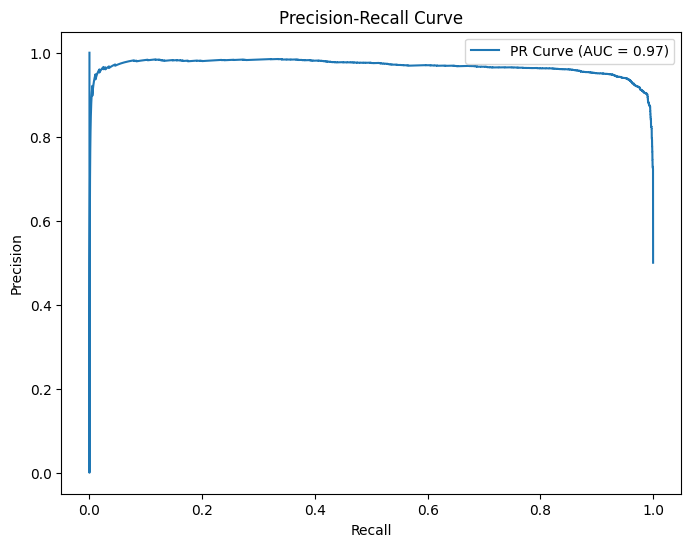

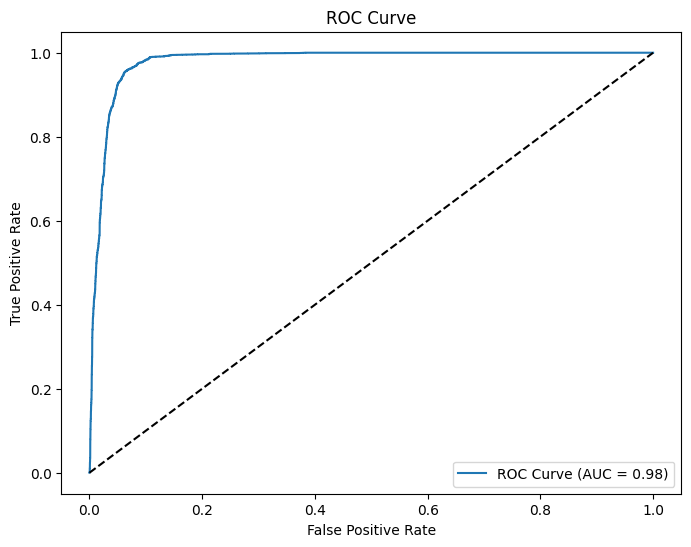

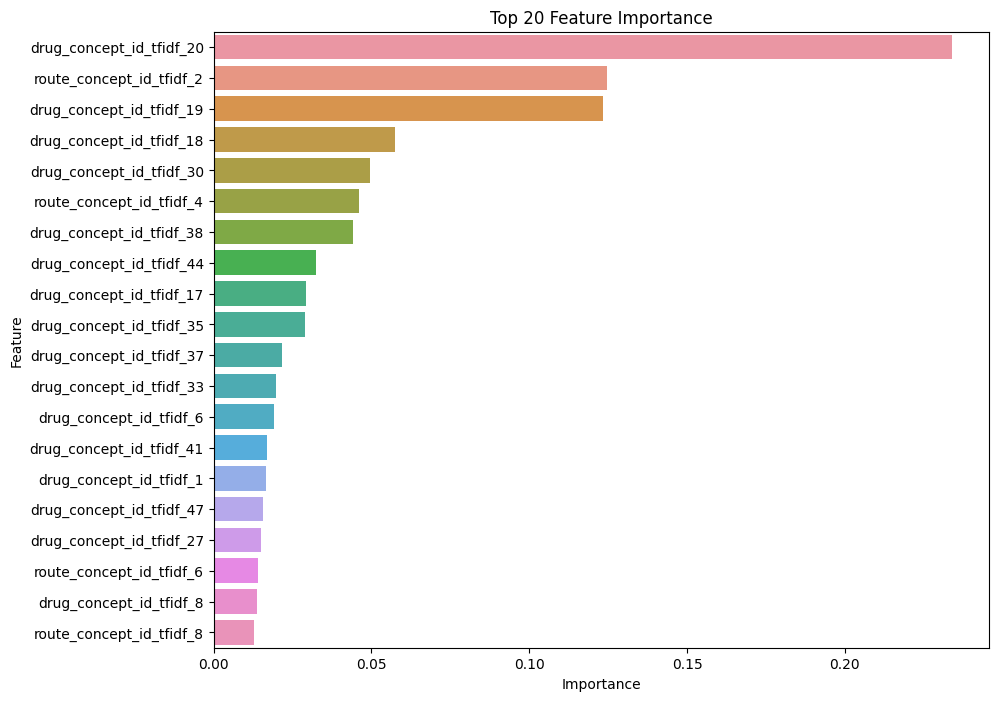

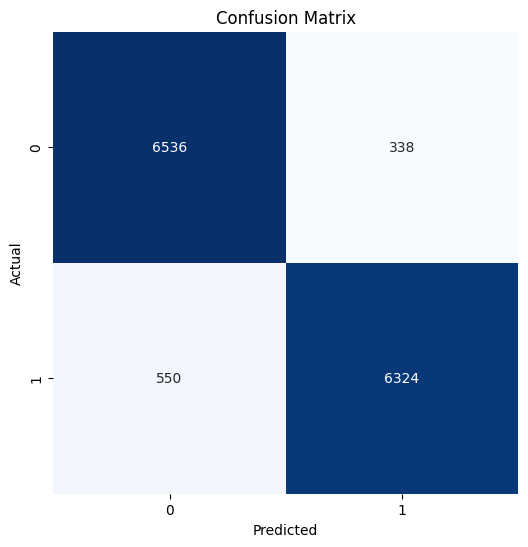

Submission file saved as 'submission.csv'


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_curve, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering function
def get_feats(mode='train'):
    path = f'/kaggle/input/phems-hackathon-early-sepsis-prediction/{mode}ing_data/'
    feats = pd.read_csv(path + f"SepsisLabel_{mode}.csv").drop_duplicates()
    feats['measurement_datetime_day'] = feats['measurement_datetime'].fillna('None').astype(str).apply(lambda x: x[:10])

    # Drug Features
    drug = pd.read_csv(path + f"drugsexposure_{mode}.csv")
    drug['measurement_datetime_day'] = drug['drug_datetime_hourly'].fillna('None').astype(str).apply(lambda x: x[:10])
    for col in ['drug_concept_id', 'route_concept_id']:
        drug[col] = drug[col].fillna('None').astype(str)
        group_df = drug.groupby(['person_id', 'measurement_datetime_day'])[col].apply(lambda x: " ".join(x)).reset_index()
        feats = feats.merge(group_df, on=['person_id', 'measurement_datetime_day'], how='left')
        feats[col] = feats[col].fillna('None')

    # Time-Based Features
    feats['measurement_datetime'] = pd.to_datetime(feats['measurement_datetime'])
    feats['dow'] = feats['measurement_datetime'].dt.dayofweek
    feats['doy'] = feats['measurement_datetime'].dt.dayofyear
    feats['hour'] = feats['measurement_datetime'].dt.hour
    feats.drop(['measurement_datetime'], axis=1, inplace=True)

    # Convert categorical columns to category dtype
    feats['measurement_datetime_day'] = feats['measurement_datetime_day'].astype('category')
    feats['drug_concept_id'] = feats['drug_concept_id'].astype('category')
    feats['route_concept_id'] = feats['route_concept_id'].astype('category')

    return feats

# Load Data
train = get_feats(mode='train')
test = get_feats(mode='test')

# Filter Rows for Training
train_0 = train[train['SepsisLabel'] == 0]  # Majority class (SepsisLabel == 0)
train_1 = train[train['SepsisLabel'] == 1]  # Minority class (SepsisLabel == 1)

# Undersampling the majority class (SepsisLabel == 0)
# Randomly sample the majority class to match the size of the minority class
train_0_undersampled = train_0.sample(n=len(train_1), random_state=2025)

# Combine the undersampled majority class with the minority class
train = pd.concat([train_0_undersampled, train_1], ignore_index=True)

# TF-IDF for Text Features
text_cols = ['drug_concept_id', 'route_concept_id']
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 1))
    train_tfidf = tfidf.fit_transform(train[col].astype(str))
    test_tfidf = tfidf.transform(test[col].astype(str))

    # Convert sparse matrix to DataFrame
    train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(train_tfidf.shape[1])])
    test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(test_tfidf.shape[1])])

    train_tfidf_df.index = train.index
    test_tfidf_df.index = test.index

    # Concatenate TF-IDF features with train/test
    train = pd.concat([train, train_tfidf_df], axis=1)
    test = pd.concat([test, test_tfidf_df], axis=1)

    # Drop original text columns
    train.drop(columns=[col], inplace=True)
    test.drop(columns=[col], inplace=True)

# Define Model Parameters with categorical support
xgb_params = {
    'booster': 'gbtree',
    'learning_rate': 0.05,
    'max_depth': 10,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': -1,
    'random_state': 2025,
    'enable_categorical': True  # Enable categorical data support
}

# Cross-Validation
sgkf = StratifiedGroupKFold(n_splits=5)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

features = [col for col in train.columns if col not in ['SepsisLabel', 'person_id']]

for fold, (train_idx, val_idx) in enumerate(sgkf.split(train, train['SepsisLabel'], groups=train['person_id'])):
    X_train, X_val = train.iloc[train_idx][features], train.iloc[val_idx][features]
    y_train, y_val = train.iloc[train_idx]['SepsisLabel'], train.iloc[val_idx]['SepsisLabel']

    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    # Out-of-fold predictions for validation
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(test[features])[:, 1] / sgkf.n_splits

    # Print evaluation metrics on train and validation sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    print(f"Fold {fold + 1}:")
    print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}, Precision: {precision_score(y_train, y_train_pred):.4f}, Recall: {recall_score(y_train, y_train_pred):.4f}, F1: {f1_score(y_train, y_train_pred):.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}, Precision: {precision_score(y_val, y_val_pred):.4f}, Recall: {recall_score(y_val, y_val_pred):.4f}, F1: {f1_score(y_val, y_val_pred):.4f}")
    print("-" * 50)

# Evaluate Model
precision, recall, _ = precision_recall_curve(train['SepsisLabel'], oof_preds)
pr_auc = auc(recall, precision)
print(f'PR-AUC: {pr_auc:.4f}')

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(train['SepsisLabel'], oof_preds)
roc_auc = roc_auc_score(train['SepsisLabel'], oof_preds)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot Feature Importance
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importance')
plt.show()

# Plot Confusion Matrix
y_pred = (oof_preds > 0.5).astype(int)  # Convert probabilities to binary predictions
cm = confusion_matrix(train['SepsisLabel'], y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Submission
sub = pd.read_csv('/kaggle/input/phems-hackathon-early-sepsis-prediction/SepsisLabel_sample_submission.csv')
sub['SepsisLabel'] = test_preds
sub.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")

# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">2.Construct features</h1></span>

Through experiments, it was found that the two features 'drug_comept_id' and 'route__comept_id 'are particularly important for the final prediction, so here we mainly construct their related features. Due to the possibility of multiple 'measurement_datetime' for a 'person_id', we will refine 'measurement_datetime' to days and then search for the data of each day and the previous day to construct features.

# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">3.Train and Predict</h1></span>


- 'weight' is a weighted training for each sample.

- word2vec_madels is a tfidf model used to construct tfidf features for text data.

Due to an imbalanced sample in this competition,here we will use repeatgroupkfold (n_repeats=2,group_col='person_id') to train lightgbm model.

We can see that the CV  fluctuates greatly and differs significantly from LB. I estimate that there will be a significant shakeup in this competition.

Good luck to everyone.